Import Dependicies

In [108]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBRegressor

Import Data

In [109]:
train_df = pd.read_csv('/content/Train.csv')


In [110]:
# Shapde and Size
print('Train Data Shape:', train_df.shape)
print('Test Data Shape:', test_df.shape)

Train Data Shape: (8523, 12)
Test Data Shape: (5681, 11)


In [111]:
# description
train_df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [112]:
train_df


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


In [113]:
# Check null Values for train and test
print('Train Data Null Values:')
print(train_df.isnull().sum())


Train Data Null Values:
Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64


In [114]:
# handle missing values by changing Item_weight with mean and Size with mode values for train and test data
train_df['Item_Weight'].fillna(train_df['Item_Weight'].mean(), inplace=True)
train_df['Outlet_Size'].fillna(train_df['Outlet_Size'].mode()[0], inplace=True)

/tmp/ipykernel_7884/411683568.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Item_Weight'].fillna(train_df['Item_Weight'].mean(), inplace=True)
/tmp/ipykernel_7884/411683568.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(v

In [115]:
train_df

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Medium,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,Medium,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


Data Visualization

/tmp/ipykernel_7884/3151815347.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train_df['Item_Weight'], kde=True)


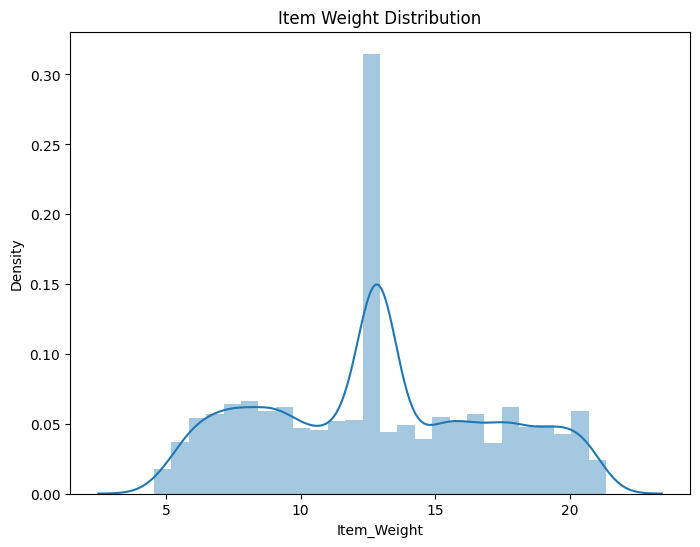

In [116]:
# Item Weight Distribution
plt.figure(figsize=(8, 6))
sns.distplot(train_df['Item_Weight'], kde=True)
plt.title('Item Weight Distribution')
plt.show()

/tmp/ipykernel_7884/2829787218.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train_df['Item_Visibility'], kde=True)


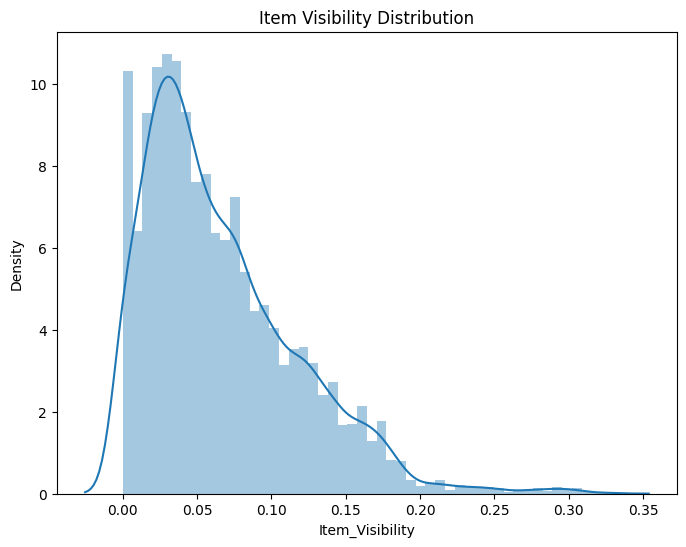

In [117]:
# Item Visibility Distrubution
plt.figure(figsize=(8, 6))
sns.distplot(train_df['Item_Visibility'], kde=True)
plt.title('Item Visibility Distribution')
plt.show()

/tmp/ipykernel_7884/2208344274.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train_df['Item_MRP'], kde=True)


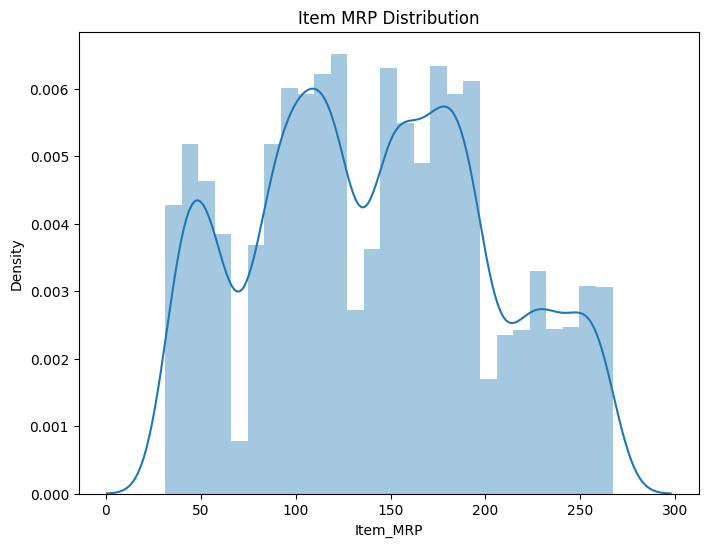

In [118]:
# Item MRP Distribution
plt.figure(figsize=(8, 6))
sns.distplot(train_df['Item_MRP'], kde=True)
plt.title('Item MRP Distribution')
plt.show()



/tmp/ipykernel_7884/3457033337.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train_df['Item_Outlet_Sales'], kde=True)


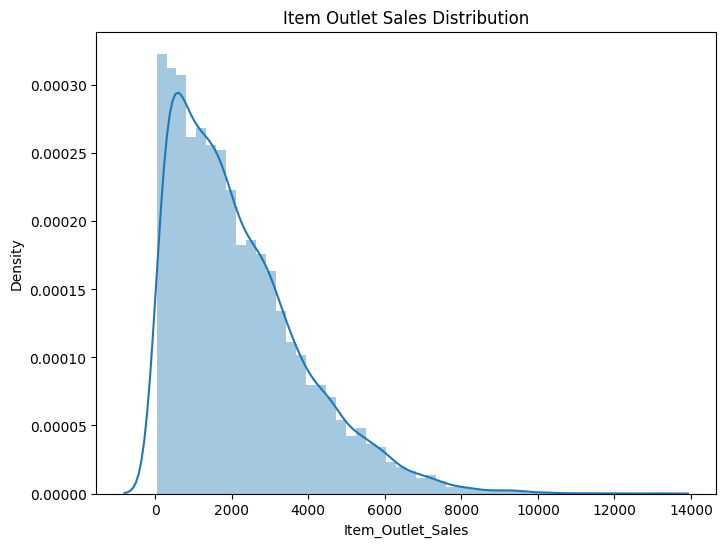

In [119]:
 # Item Outlet Sales Distrubution
 plt.figure(figsize=(8, 6))
 sns.distplot(train_df['Item_Outlet_Sales'], kde=True)
 plt.title('Item Outlet Sales Distribution')
 plt.show()

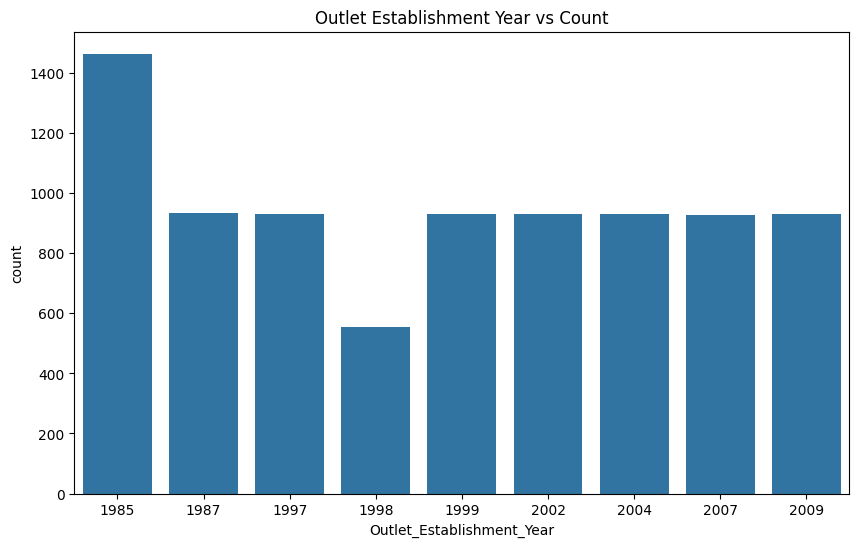

In [120]:
# Outlet Establushment Year vs count
plt.figure(figsize=(10, 6))
sns.countplot(x='Outlet_Establishment_Year', data=train_df)
plt.title('Outlet Establishment Year vs Count')
plt.show()


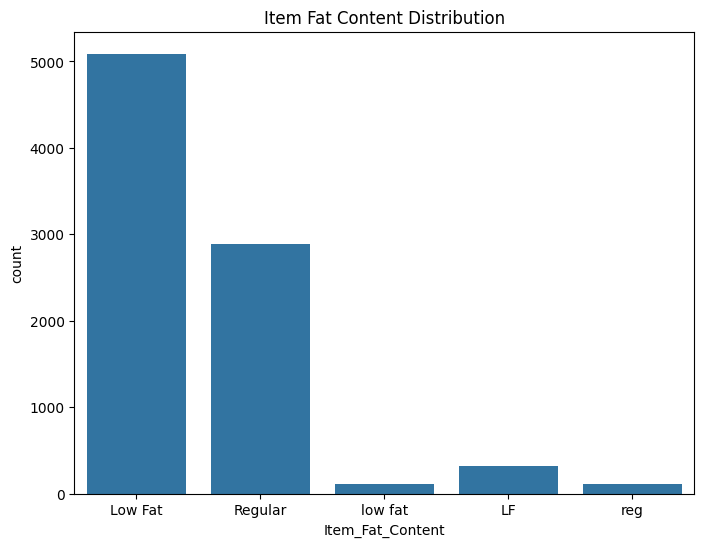

In [121]:
# Item Fat Content Distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='Item_Fat_Content', data=train_df)
plt.title('Item Fat Content Distribution')
plt.show()

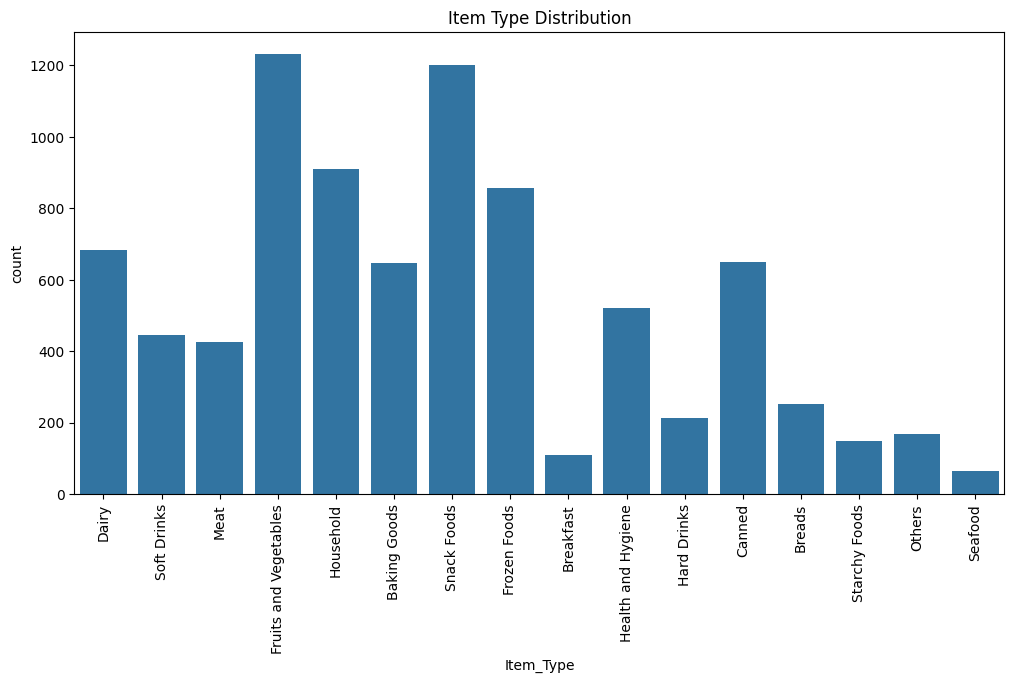

In [122]:
# Item_typeColumn
plt.figure(figsize=(12, 6))
sns.countplot(x='Item_Type', data=train_df)
plt.title('Item Type Distribution')
plt.xticks(rotation=90)
plt.show()

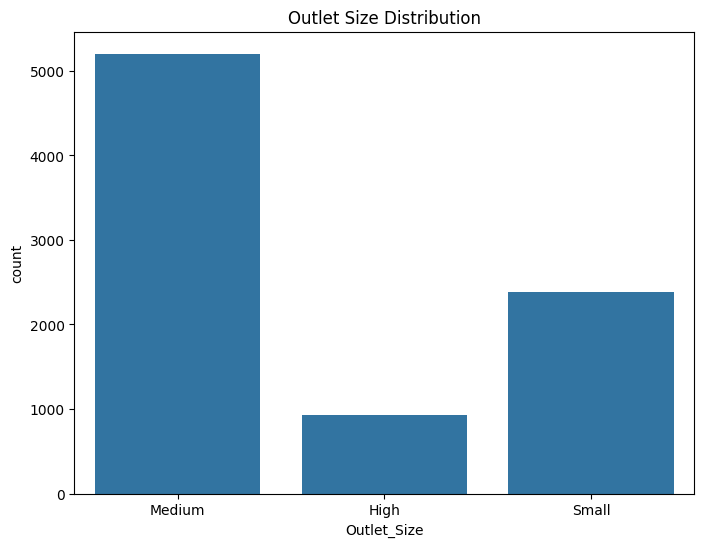

In [123]:
# outlet_size Column
plt.figure(figsize=(8, 6))
sns.countplot(x='Outlet_Size', data=train_df)
plt.title('Outlet Size Distribution')
plt.show()
#

Data PReprocessing

In [124]:
# identifying categorical and numeircal features
numerical_cols = train_df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_df.select_dtypes(include='object').columns.tolist()

print('Numerical Columns:', numerical_cols)
print('Categorical Columns:', categorical_cols)

Numerical Columns: ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year', 'Item_Outlet_Sales']
Categorical Columns: ['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']


In [125]:
train_df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5089
Regular,2889
LF,316
reg,117
low fat,112


In [126]:
train_df['Item_Fat_Content'] = train_df['Item_Fat_Content'].replace({'LF': 'Low Fat', 'low fat': 'Low Fat', 'reg': 'Regular'})
train_df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


Label Encoder


In [128]:
encoder = LabelEncoder()

In [129]:
train_df['Item_Identifier'] = encoder.fit_transform(train_df['Item_Identifier'])

train_df['Item_Fat_Content'] = encoder.fit_transform(train_df['Item_Fat_Content'])

train_df['Item_Type'] = encoder.fit_transform(train_df['Item_Type'])

train_df['Outlet_Identifier'] = encoder.fit_transform(train_df['Outlet_Identifier'])

train_df['Outlet_Size'] = encoder.fit_transform(train_df['Outlet_Size'])

train_df['Outlet_Location_Type'] = encoder.fit_transform(train_df['Outlet_Location_Type'])

train_df['Outlet_Type'] = encoder.fit_transform(train_df['Outlet_Type'])

In [130]:
train_df





,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,156,9.300,0,0.016047,4,249.8092,9,1999,1,0,1,3735.1380
1,8,5.920,1,0.019278,14,48.2692,3,2009,1,2,2,443.4228
2,662,17.500,0,0.016760,10,141.6180,9,1999,1,0,1,2097.2700
3,1121,19.200,1,0.000000,6,182.0950,0,1998,1,2,0,732.3800
4,1297,8.930,0,0.000000,9,53.8614,1,1987,0,2,1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,370,6.865,0,0.056783,13,214.5218,1,1987,0,2,1,2778.3834
8519,897,8.380,1,0.046982,0,108.1570,7,2002,1,1,1,549.2850
8520,1357,10.600,0,0.035186,8,85.1224,6,2004,2,1,1,1193.1136
8521,681,7.210,1,0.145221,13,103.1332,3,2009,1,2,2,1845.5976


In [131]:
 X = train_df.drop(columns='Item_Outlet_Sales', axis=1)
 Y = train_df['Item_Outlet_Sales']

Model Training and Evalution

In [132]:
# fit data XGboostRegressor
model = XGBRegressor()
model.fit(X, Y)



XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [133]:
# prediction on traiing data
training_data_prediction = model.predict(X)

In [134]:
# accuracy
r2_train = metrics.r2_score(Y, training_data_prediction)
print('R Squared Value:', r2_train)


R Squared Value: 0.8521481747786491
